# SignalScope AI — Baseline Classification Model

This notebook builds the first machine-learning baseline for SignalScope AI.

The goal is to classify particle-collision events as **signal** or **background** and establish a baseline before exploring more advanced models and explainability methods.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)

print("SignalScope AI environment ready!")

SignalScope AI environment ready!


## 1. Load the Dataset

We begin with a 10,000-event subset of the HIGGS particle-collision dataset used during the exploratory data analysis stage of the project.


In [ ]:
df = pd.read_csv(
    "sample_data/higgs_train_10k.csv.zip",
    compression="zip",
    header=None
)

print("Dataset shape:", df.shape)

Dataset shape: (10000, 29)


In [ ]:
#Define target and features

y = df.iloc[:, 0]
X = df.iloc[:,1:]

print("Features matrix shape:", X.shape)
print("Taarget shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Features matrix shape: (10000, 28)
Taarget shape: (10000,)

Target distribution:
0
1    5295
0    4705
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTest target distribution:")
print(y_test.value_counts())

Training set: (8000, 28)
Test set: (2000, 28)

Training target distribution:
0
1    4236
0    3764
Name: count, dtype: int64

Test target distribution:
0
1    1059
0     941
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Create and train the baseline model
model = LogisticRegression(
    max_iter= 1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Baseline model trained successfully!")



Baseline model trained successfully!


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
#Make predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

#Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC AUC Score:", roc_auc)

Accuracy: 0.628
Precision: 0.6296296296296297
Recall: 0.7223796033994334
F1 Score: 0.6728232189973615
ROC AUC Score: 0.6731763267935684


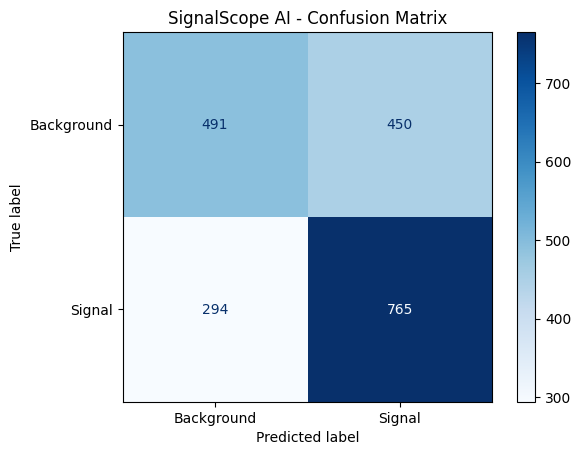

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Background", "Signal"],
    cmap="Blues"
)
plt.title("SignalScope AI - Confusion Matrix")
plt.show()

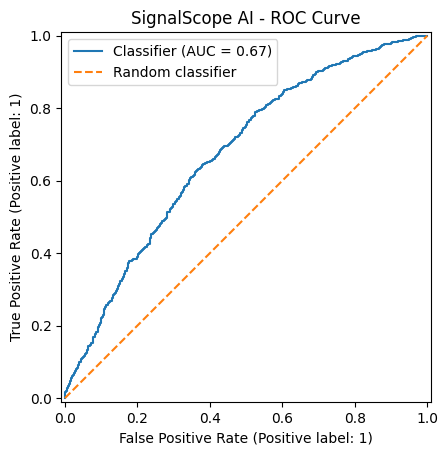

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)
plt.plot([0,1],[0,1], "--", label ="Random classifier")
plt.title("SignalScope AI - ROC Curve")
plt.legend()
plt.show()

### Baseline Model Interpretation

The Logistic Regression baseline achieved an ROC-AUC score of approximately **0.67**.

The model correctly identified **765 out of 1,059 signal events**, corresponding to a recall of approximately **72.2%**. However, it also classified **450 background events as signal**, indicating that a linear decision boundary is not sufficient to fully capture the complex relationships in the data.

These results provide a useful baseline for comparison with more powerful non-linear models.

## 7. Random Forest Model

To improve upon the linear baseline, we train a Random Forest classifier.

Unlike Logistic Regression, Random Forest can capture non-linear relationships
and interactions between the collision-event features.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("Random Forest trained successfully!")

Random Forest trained successfully!


In [ ]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1 Score:", rf_f1)
print("ROC AUC Score:", rf_auc)

Accuracy: 0.716
Precision: 0.7166813768755517
Recall: 0.7667610953729934
F1 Score: 0.7408759124087592
ROC AUC Score: 0.7934133719477502


### Random Forest Results

The Random Forest model significantly outperformed the Logistic Regression baseline.

Its ROC-AUC score increased from approximately **0.67 to 0.79**, while the F1 score improved from **0.67 to 0.74**.

The improvement suggests that non-linear relationships and feature interactions play an important role in distinguishing signal events from background events in the HIGGS dataset.

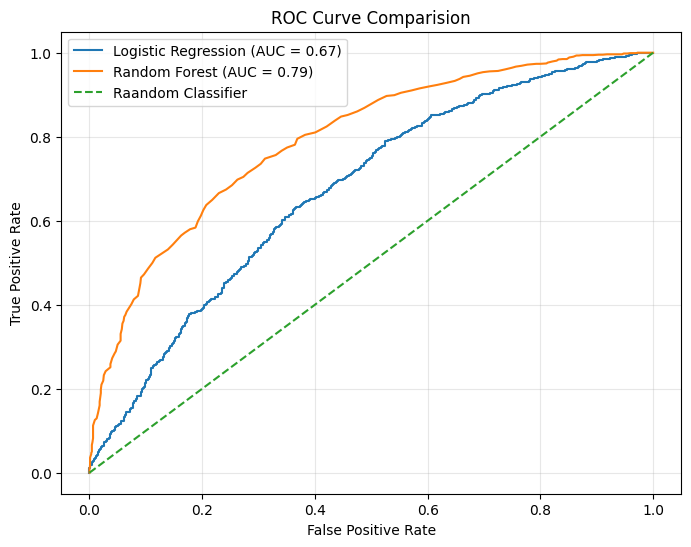

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Logistic Regression
lr_prob = model.predict_proba(X_test_scaled)[:,1]
lr_auc = roc_auc_score(y_test, lr_prob)

# Random Forest
rf_prob = rf_model.predict_proba(X_test)[:,1]
rf_auc = roc_auc_score(y_test, rf_prob)

# Calculate Roc Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

# Plot Roc Curves

plt.figure(figsize=(8, 6))
plt.plot(
    fpr_lr,
    tpr_lr,
    label="Logistic Regression (AUC = {:.2f})".format(lr_auc)
)
plt.plot(
    fpr_rf,
    tpr_rf,
    label="Random Forest (AUC = {:.2f})".format(rf_auc)
)

plt.plot([0,1], [0,1], linestyle="--", label="Raandom Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparision")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 8. Feature Importance

Random Forest provides feature importance scores that help us examine
which input variables contribute most strongly to the classification
of signal and background events.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
print(feature_importance.head(10))

    Feature  Importance
25       26    0.099429
27       28    0.061347
26       27    0.060739
24       25    0.050098
22       23    0.049546
5         6    0.048072
3         4    0.039239
0         1    0.038728
9        10    0.038382
21       22    0.036697


### Top 10 Most Important Features

The following plot shows the ten features with the highest importance
scores according to the Random Forest model.

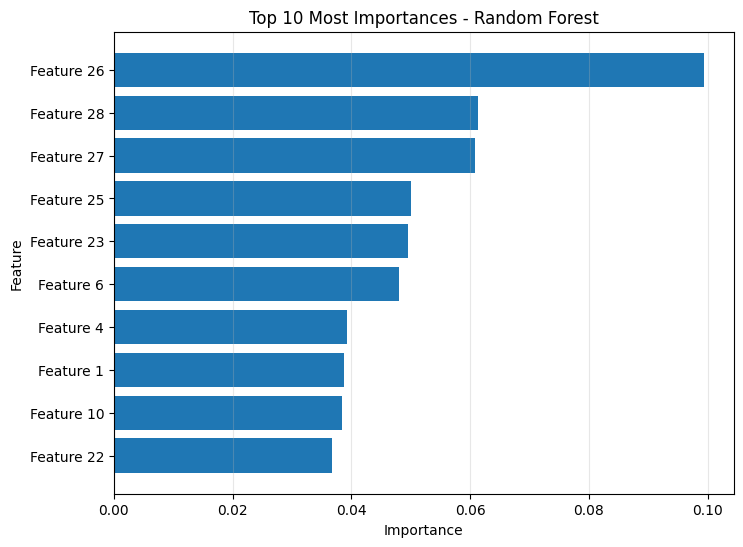

In [ ]:
top_10 = feature_importance.head(10).copy()

# Convert feature numbers into readable labels
top_10["Feature"] = top_10["Feature"].apply(
    lambda x : f"Feature {x}"
)

top_10 = top_10.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(8,6))

plt.barh(
    top_10["Feature"],
    top_10["Importance"]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Most Importances - Random Forest")
plt.grid(axis="x", alpha=0.3)
plt.show()

In [36]:
feature_names = [
    "lepton_pt",
    "lepton_eta",
    "lepton_phi",
    "missing_energy_magnitude",
    "missing_energy_phi",
    "jet1_pt",
    "jet1_eta",
    "jet1_phi",
    "jet1_btag",
    "jet2_pt",
    "jet2_eta",
    "jet2_phi",
    "jet2_btag",
    "jet3_pt",
    "jet3_eta",
    "jet3_phi",
    "jet3_btag",
    "jet4_pt",
    "jet4_eta",
    "jet4_phi",
    "jet4_btag",
    "m_jj",
    "m_jjj",
    "m_lv",
    "m_jlv",
    "m_bb",
    "m_wbb",
    "m_wwbb"
]

print("Feature names:", len(feature_names))
print("Model features:", len(rf_model.feature_importances_))

Feature names: 28
Model features: 28


In [37]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_

})

top_10 = (
    feature_importance.sort_values("Importance", ascending = False)
    .head(10)
)
print(top_10)

                     Feature  Importance
25                      m_bb    0.099429
27                    m_wwbb    0.061347
26                     m_wbb    0.060739
24                     m_jlv    0.050098
22                     m_jjj    0.049546
5                    jet1_pt    0.048072
3   missing_energy_magnitude    0.039239
0                  lepton_pt    0.038728
9                    jet2_pt    0.038382
21                      m_jj    0.036697


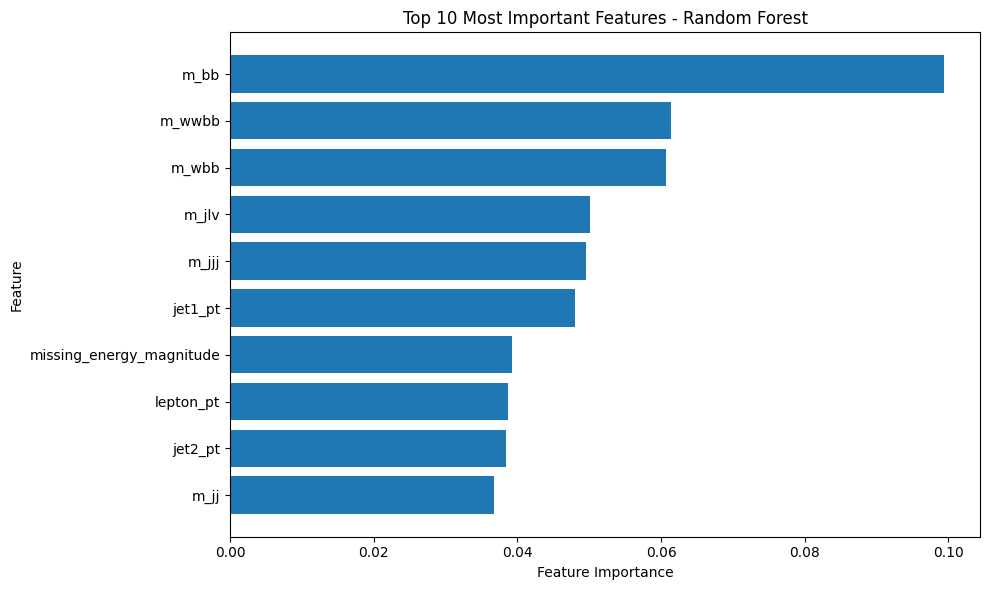

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize = (10,6))
plt.barh(
    top_10["Feature"][::-1],
    top_10["Importance"][::-1]
)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Features - Random Forest")

plt.tight_layout()
plt.show()

In [39]:
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# First 21 columns = low-level features
X_train_low = X_train.iloc[:, :21]
X_test_low = X_test.iloc[:, :21]

# Use exactly the same Random Forest configuration
rf_low = clone(rf_model)

rf_low.fit(X_train_low, y_train)

low_pred = rf_low.predict(X_test_low)
low_prob = rf_low.predict_proba(X_test_low)[:,1]

In [40]:
low_results = {
    "Accuracy": accuracy_score(y_test, low_pred),
    "Precision": precision_score(y_test, low_pred),
    "Recall": recall_score(y_test, low_pred),
    "F1 Score": f1_score(y_test, low_pred),
    "ROC AUC Score": roc_auc_score(y_test, low_prob)
}
print(low_results)

{'Accuracy': 0.621, 'Precision': 0.6261525565800503, 'Recall': 0.7053824362606232, 'F1 Score': 0.6634103019538188, 'ROC AUC Score': np.float64(0.6650189308984575)}


In [41]:
all_pred = rf_model.predict(X_test)
all_prob = rf_model.predict_proba(X_test)[:, 1]

all_results = {
    "Accuracy": accuracy_score(y_test, all_pred),
    "Precision": precision_score(y_test, all_pred),
    "Recall": recall_score(y_test, all_pred),
    "F1 Score": f1_score(y_test, all_pred),
    "ROC AUC Score": roc_auc_score(y_test, all_prob)
}
print(all_results)


{'Accuracy': 0.716, 'Precision': 0.7166813768755517, 'Recall': 0.7667610953729934, 'F1 Score': 0.7408759124087592, 'ROC AUC Score': np.float64(0.7934133719477502)}


In [44]:
import pandas as pd

comparision = pd.DataFrame({
    "Low-Level Only (21)": low_results,
    "All Features (28)": all_results
}).T

comparision.round(3)

,Accuracy,Precision,Recall,F1 Score,ROC AUC Score
Low-Level Only (21),0.621,0.626,0.705,0.663,0.665
All Features (28),0.716,0.717,0.767,0.741,0.793


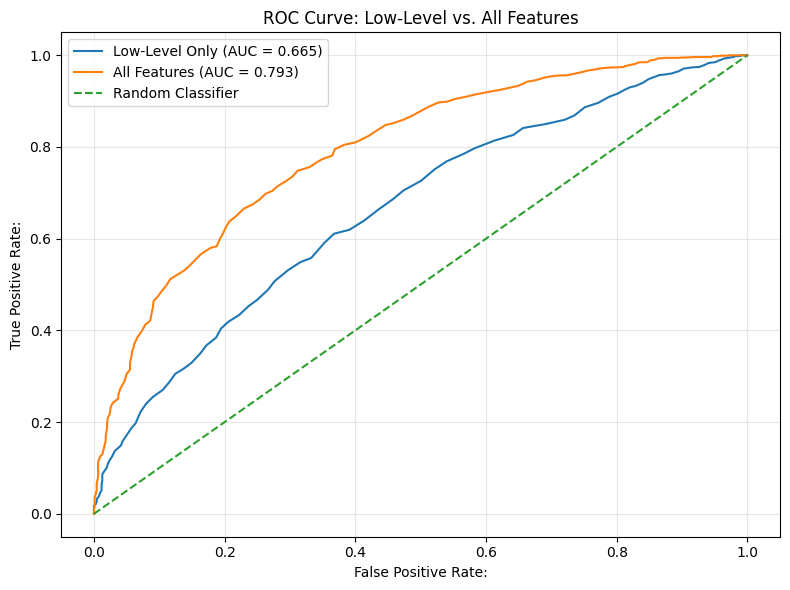

In [46]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Low-level model
fpr_low, tpr_low, _ = roc_curve(y_test, low_prob)
auc_low = auc(fpr_low, tpr_low)

# All-feature model
fpr_all, tpr_all, _ = roc_curve(y_test, all_prob)
auc_all = auc(fpr_all, tpr_all)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_low,
    tpr_low,
    label =f"Low-Level Only (AUC = {auc_low:.3f})"
)
plt.plot(
    fpr_all,
    tpr_all,
    label =f"All Features (AUC = {auc_all:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate:")
plt.ylabel("True Positive Rate:")
plt.title("ROC Curve: Low-Level vs. All Features")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Experiment 1 — Impact of Physics-Engineered Features

To investigate the contribution of physics-engineered high-level features,
two Random Forest classifiers were trained using the same train/test split
and model configuration:

1. **Low-Level Model:** 21 detector-level features
2. **All-Feature Model:** 21 low-level + 7 high-level physics features

The ROC-AUC increased from **0.665 to 0.793** when the high-level features
were included.

This result suggests that physics-engineered variables provide substantial
additional information for distinguishing Higgs signal events from
background events.